In [2]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv('C:\MACHINE LEARNING\TIME SERIES\DATASETS\yearly-water-usage.csv')
df['Year'] = pd.to_datetime(df['Year'], format = 'ISO8601')
df= df.sort_values('Year')
df = df.set_index('Year')

<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
<>:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
C:\Users\Purushottam\AppData\Local\Temp\ipykernel_25060\3266068256.py:1: SyntaxWarning: "\M" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\M"? A raw string is also an option.
  df = pd.read_csv('C:\MACHINE LEARNING\TIME SERIES\DATASETS\yearly-water-usage.csv')


In [4]:
def features (df):
    df['Lag 1'] = df['Water'].shift(1)
    df['Lag 12'] = df['Water'].shift(12)
    df['MA 6'] = df['Water'].shift(1).rolling(6).mean()
    df['MA 12'] = df['Water'].shift(1).rolling(12).mean()
    df['STD 6'] = df['Water'].shift(1).rolling(6).std()
    df['STD 12'] = df['Water'].shift(1).rolling(12).std()
    return df

def time(df):
    df['Year'] = df.index.year
    return df

In [5]:
df = features(df)
df = time(df)

df.dropna(inplace = True)

In [6]:
train = df[(df.index >= '1885-01-01') & (df.index < '1940-01-01')]
test = df[(df.index >= '1940-01-01') & (df.index <= '1963-01-01')]

In [7]:
Features = ['Year', 'MA 6', 'MA 12', 'Lag 1', 'Lag 12', 'STD 6', 'STD 12']
Target = ['Water']

x_train = train[Features]
y_train = train[Target]

x_test = test[Features]
y_test = test[Target]

In [8]:
model = XGBRegressor(n_estimators = 1500, learning_rate = 0.005
                     , max_depth  = 5)

In [9]:
def validate(x_train, y_train, x_test, y_test):
    history_x = x_train.copy()
    history_y = y_train.copy()

    predictions = []

    for i in range(len(x_test)):
        model.fit(history_x, history_y)

        pred = model.predict(x_test.iloc[[i]])
        predictions.append(pred[0])

        history_x = pd.concat([history_x, x_test.iloc[[i]]])
        history_y = pd.concat([history_y, y_test.iloc[[i]]])

    error = mean_absolute_error(y_test, predictions)

    residuals = y_test.squeeze() - predictions

    return error, x_test, predictions, residuals

In [10]:
mae, x_test, pred ,residuals = validate(x_train, y_train, x_test, y_test)

In [12]:
print (mae)

20.320706685384113


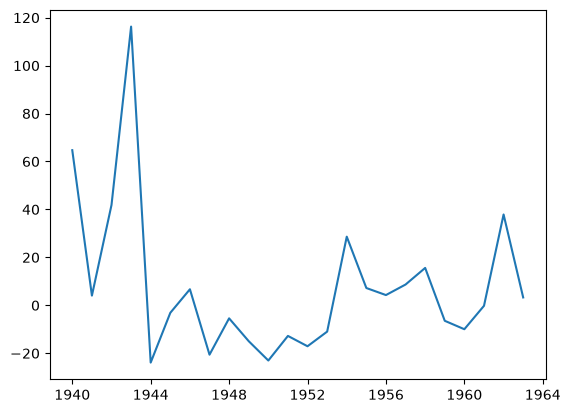

In [13]:
import matplotlib.pyplot as plt

plt.plot(residuals)


In [16]:
df['Persistence'] = df['Water'].shift(1)
df.dropna(inplace = True)

mae = mean_absolute_error(df['Water'].values, df['Persistence'])
print (mae)

20.88679245283019
